# 01 — EDA: SILRAD Dataset

SILRAD contains ~200 K Sysmon events pre-embedded with FastText.  
All feature columns are float32 vectors; `class` is the label (0 = benign, 1 = ransomware).

**Goals:**
- Inspect class balance
- Distribution of feature values
- Top features by mutual information
- t-SNE / UMAP projection of benign vs ransomware

In [3]:
import sys
sys.path.insert(0, r'h:\Challenge-3-4\cyber-anomaly-detection')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

In [4]:
from data.ingest.silrad import load

X_train, y_train, feat_names = load('train')
X_test,  y_test,  _          = load('test')

print(f'Train: {X_train.shape}  labels: {np.unique(y_train, return_counts=True)}')
print(f'Test : {X_test.shape}   labels: {np.unique(y_test,  return_counts=True)}')
print(f'Features ({len(feat_names)}):')
print("\n".join(f"{i:03d}: {feature}" for i, feature in enumerate(feat_names)))

Train: (39999, 36)  labels: (array([0, 1], dtype=int8), array([38818,  1181]))
Test : (156841, 36)   labels: (array([0, 1], dtype=int8), array([137312,  19529]))
Features (36):
000: event.code
001: CallTrace
002: CommandLine
003: Company
004: CurrentDirectory
005: Description
006: Details
007: EventType
008: GrantedAccess
009: Image
010: ImageLoaded
011: IntegrityLevel
012: IsExecutable
013: OriginalFileName
014: ParentCommandLine
015: ParentImage
016: ParentProcessGuid
017: ParentProcessId
018: ParentUser
019: ProcessGuid
020: ProcessId
021: Product
022: RuleName
023: Signature
024: SignatureStatus
025: Signed
026: SourceThreadId
027: SourceUser
028: TargetImage
029: TargetObject
030: TargetProcessGUID
031: TargetProcessId
032: TargetUser
033: TerminalSessionId
034: User
035: task


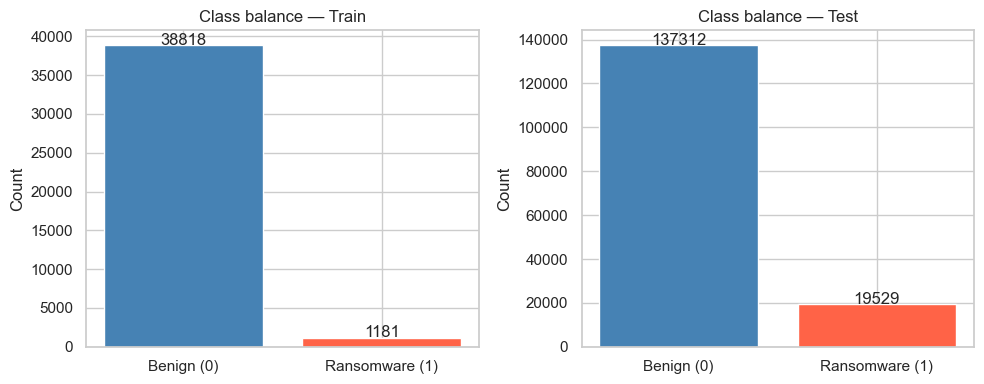

In [5]:
# Class balance
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i, (X, y, title) in enumerate([(X_train, y_train, 'Train'), (X_test, y_test, 'Test')]):
    vals, cnts = np.unique(y, return_counts=True)
    ax[i].bar(['Benign (0)', 'Ransomware (1)'], cnts, color=['steelblue', 'tomato'])
    ax[i].set_title(f'Class balance — {title}')
    ax[i].set_ylabel('Count')
    for j, c in enumerate(cnts):
        ax[i].text(j, c + 50, str(c), ha='center')
plt.tight_layout()
plt.show()

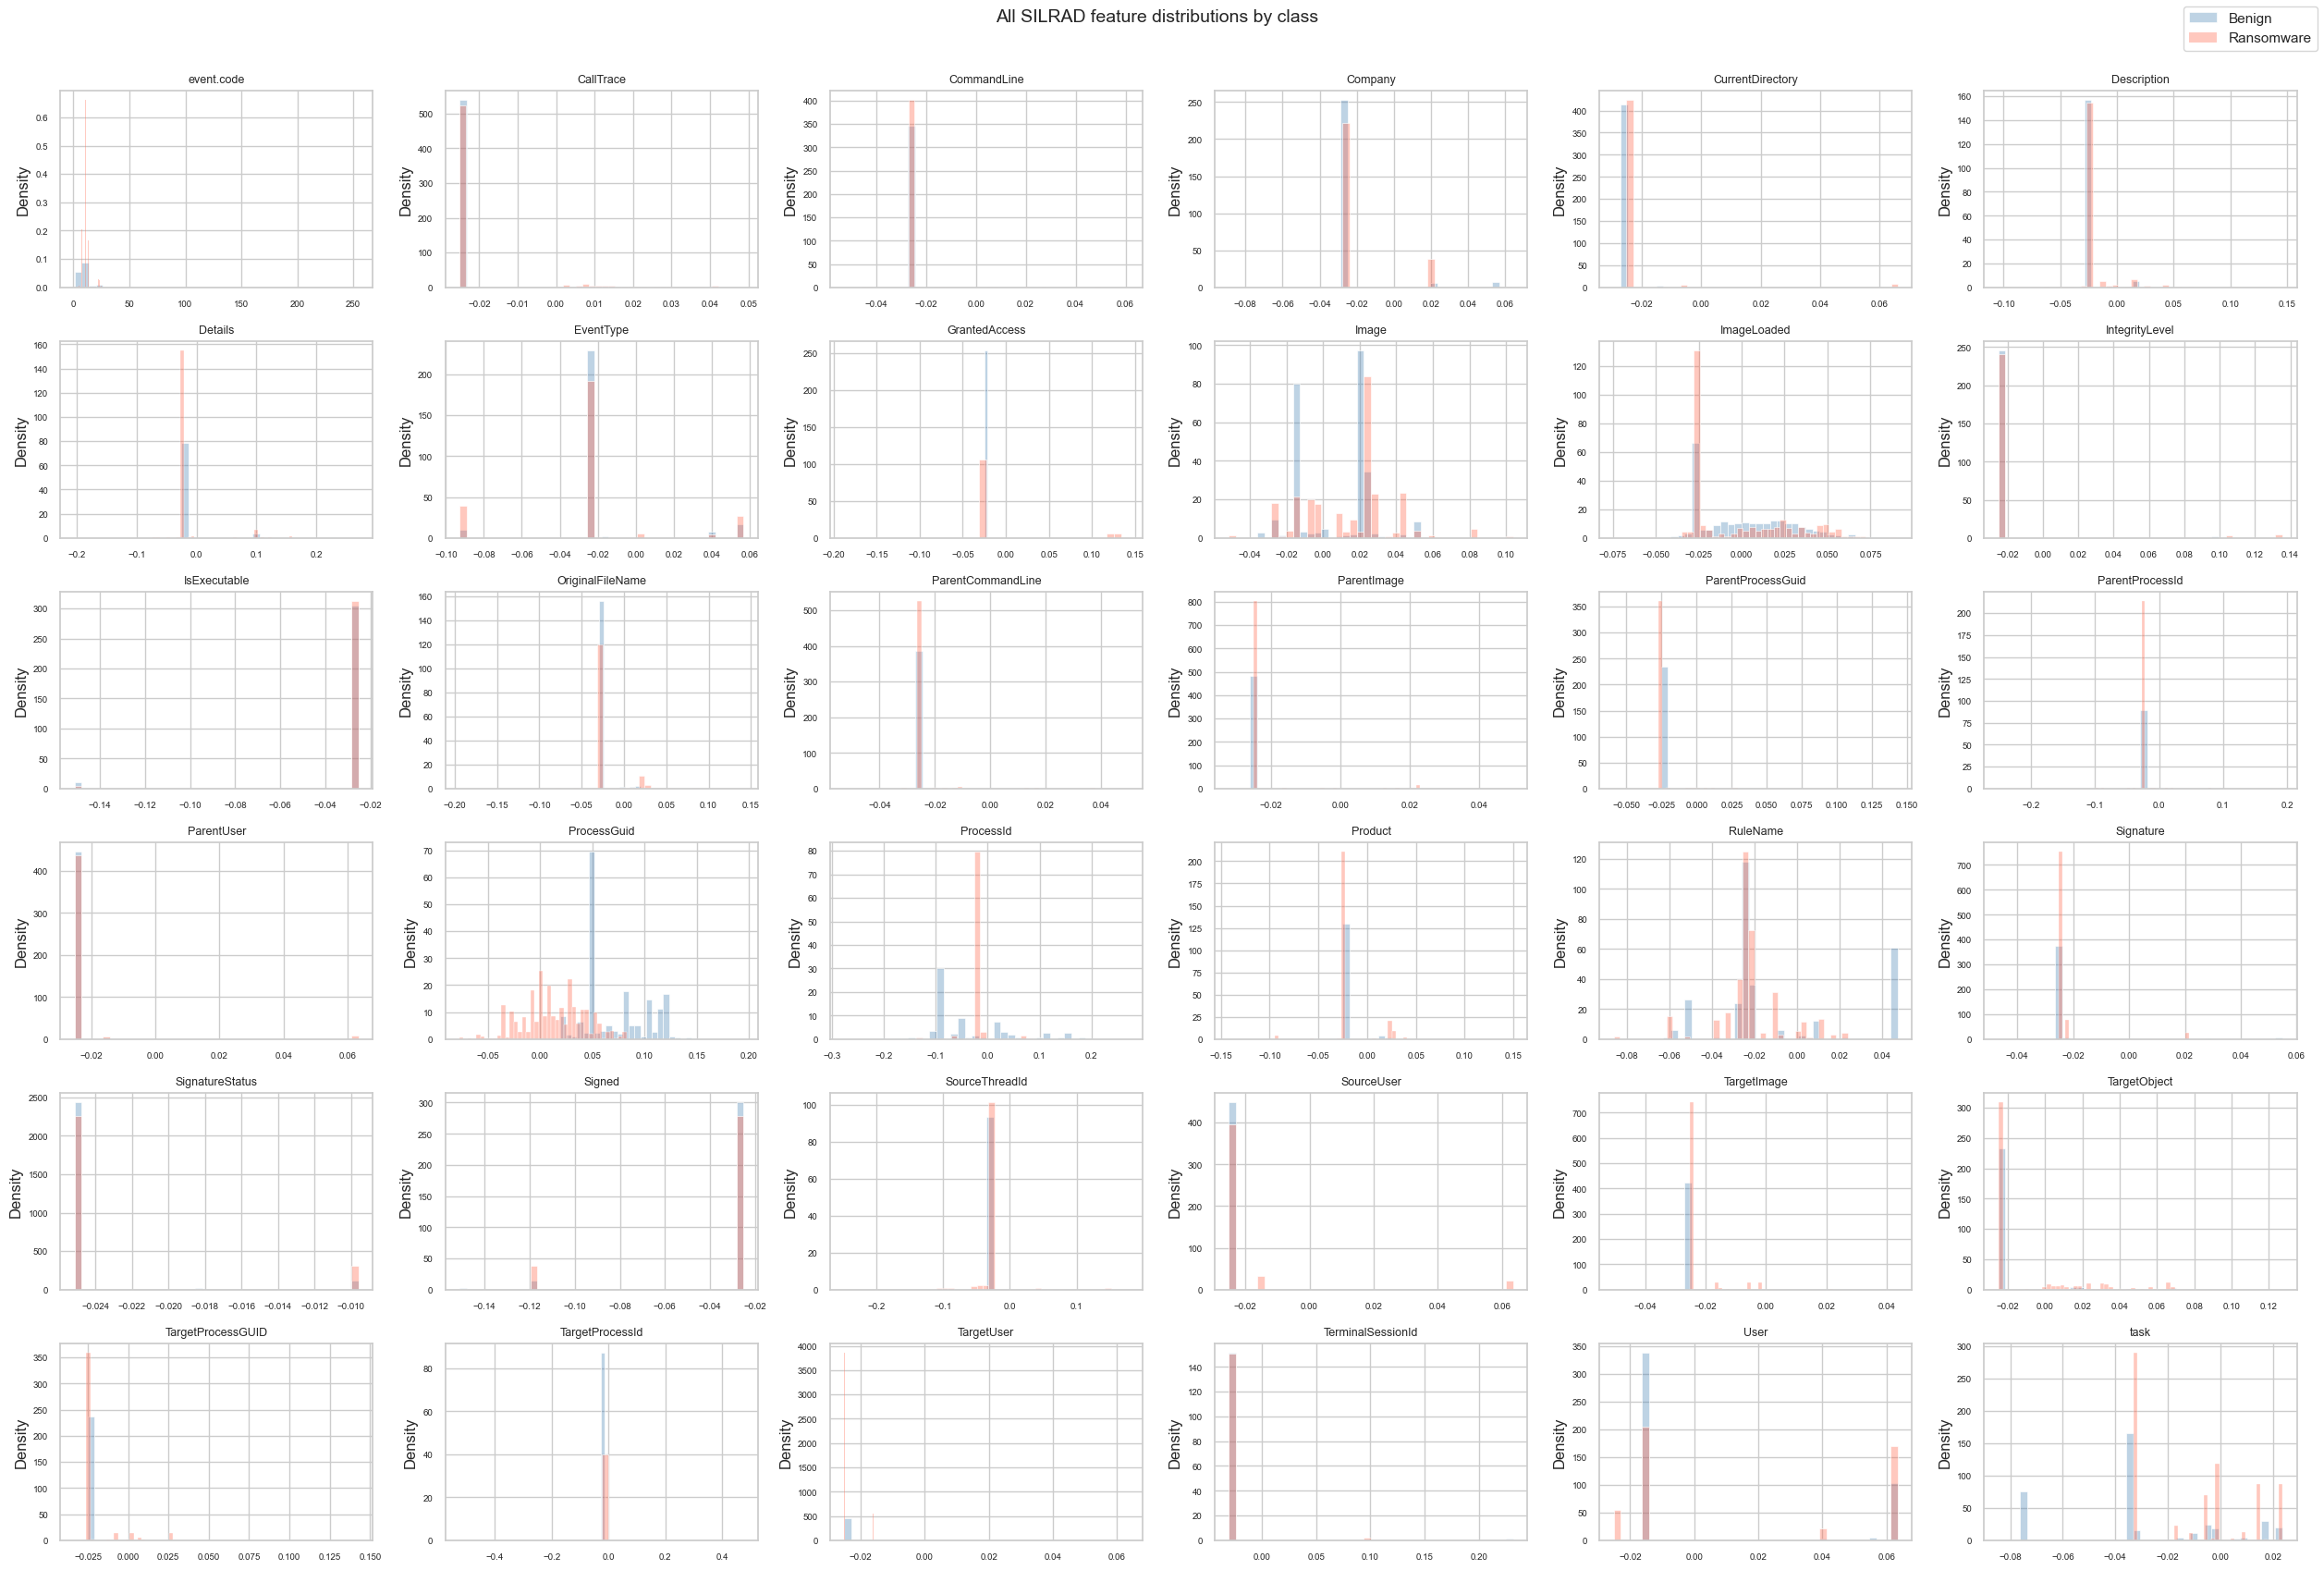

All features ranked by class separability (|Cohen's d|):


,feature,cohens_d_abs
0,ProcessGuid,1.967610
1,task,0.745503
2,CallTrace,0.479269
3,RuleName,0.452682
4,TargetUser,0.445214
5,GrantedAccess,0.442480
6,TargetImage,0.435911
7,SourceUser,0.364991
8,event.code,0.364396
9,Image,0.359977


C:\Users\cesar\AppData\Local\Temp\ipykernel_6964\2255204742.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sep_df, x='cohens_d_abs', y='feature', ax=ax, palette='magma')


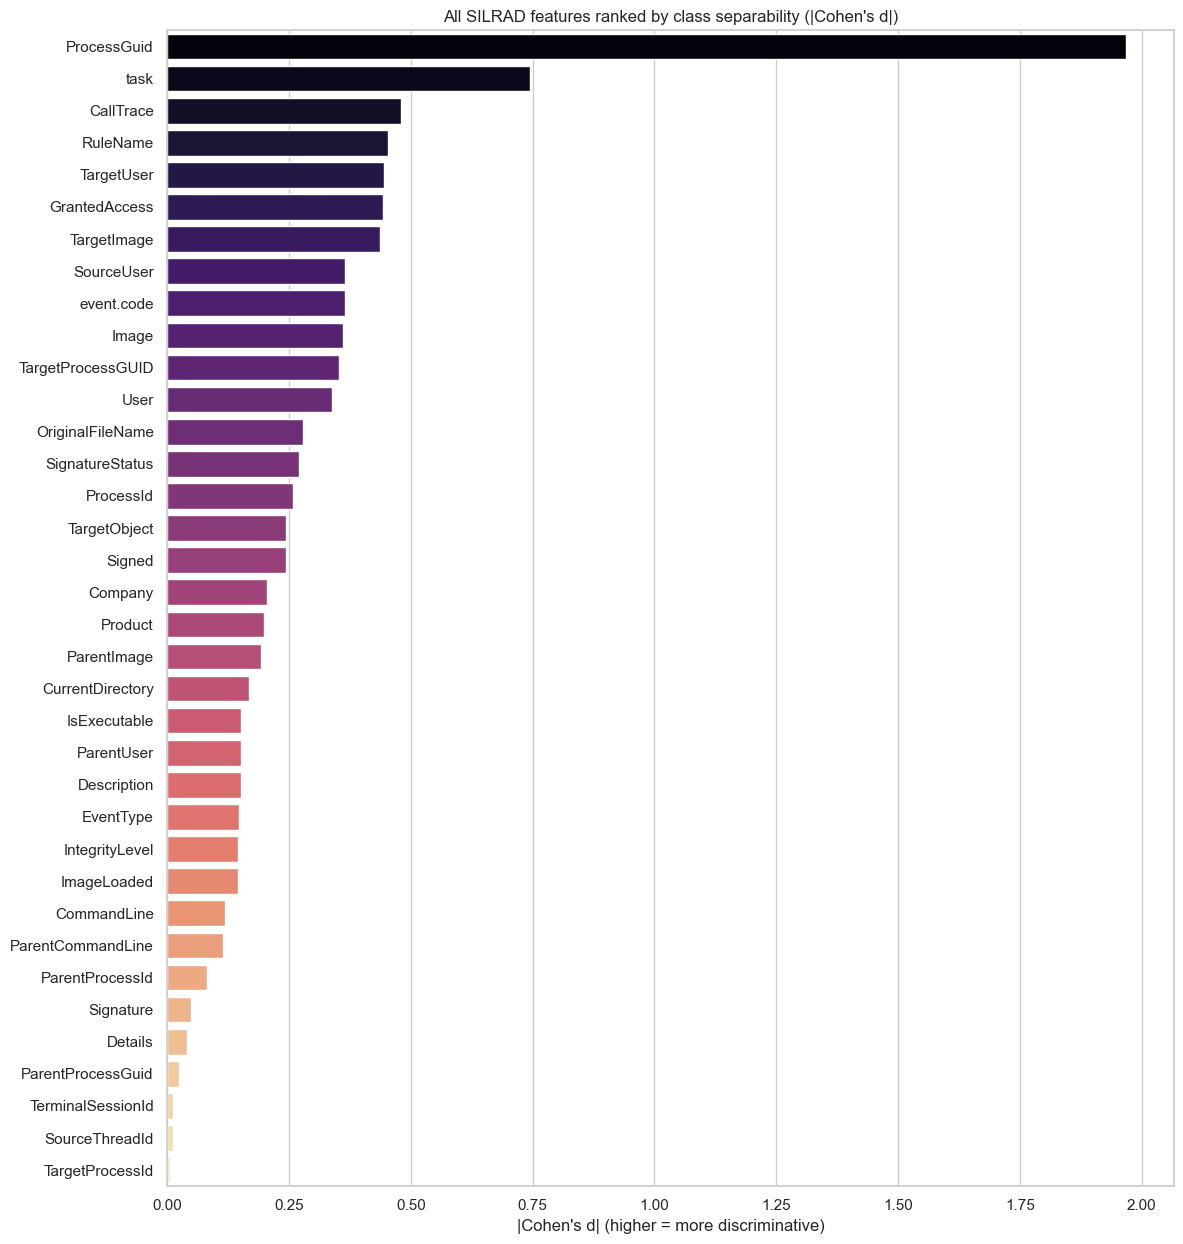

In [6]:
# Feature value distributions (ALL features) + separability ranking
import math

df_train = pd.DataFrame(X_train, columns=feat_names)
df_train['label'] = y_train.astype(int)

n_features = len(feat_names)
ncols = 6
nrows = math.ceil(n_features / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 2.8 * nrows))
axes = np.array(axes).reshape(-1)

separability = []

for i, feature in enumerate(feat_names):
    ax = axes[i]
    benign = df_train.loc[df_train['label'] == 0, feature].dropna().values
    ransomware = df_train.loc[df_train['label'] == 1, feature].dropna().values

    # Robust histogram density overlay (more stable than KDE for all features)
    sns.histplot(benign, bins=40, stat='density', color='steelblue', alpha=0.35, ax=ax, label='Benign' if i == 0 else None)
    sns.histplot(ransomware, bins=40, stat='density', color='tomato', alpha=0.35, ax=ax, label='Ransomware' if i == 0 else None)
    ax.set_title(feature, fontsize=9)
    ax.tick_params(labelsize=7)

    # Simple effect size proxy: absolute Cohen's d
    mu0, mu1 = benign.mean(), ransomware.mean()
    sd0, sd1 = benign.std(ddof=1), ransomware.std(ddof=1)
    pooled = np.sqrt((sd0 ** 2 + sd1 ** 2) / 2)
    d = 0.0 if pooled == 0 else abs((mu1 - mu0) / pooled)
    separability.append((feature, d))

# Hide unused axes
for j in range(n_features, len(axes)):
    axes[j].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper right')

plt.suptitle('All SILRAD feature distributions by class', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

# Rank all features by class separability
sep_df = pd.DataFrame(separability, columns=['feature', 'cohens_d_abs']).sort_values('cohens_d_abs', ascending=False).reset_index(drop=True)
print('All features ranked by class separability (|Cohen\'s d|):')
display(sep_df)

fig_height = max(8, 0.35 * len(sep_df))
fig, ax = plt.subplots(figsize=(12, fig_height))
sns.barplot(data=sep_df, x='cohens_d_abs', y='feature', ax=ax, palette='magma')
ax.set_title('All SILRAD features ranked by class separability (|Cohen\'s d|)')
ax.set_xlabel('|Cohen\'s d| (higher = more discriminative)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

All features ranked by mutual information with class label:


,feature,mi
0,ProcessId,0.128660
1,ProcessGuid,0.122745
2,Image,0.087557
3,ImageLoaded,0.029237
4,RuleName,0.028247
5,TargetObject,0.027011
6,task,0.024587
7,event.code,0.022690
8,TargetProcessGUID,0.020072
9,SourceThreadId,0.020051


C:\Users\cesar\AppData\Local\Temp\ipykernel_6964\3528515941.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x='mi', y='feature', ax=ax, palette='viridis')


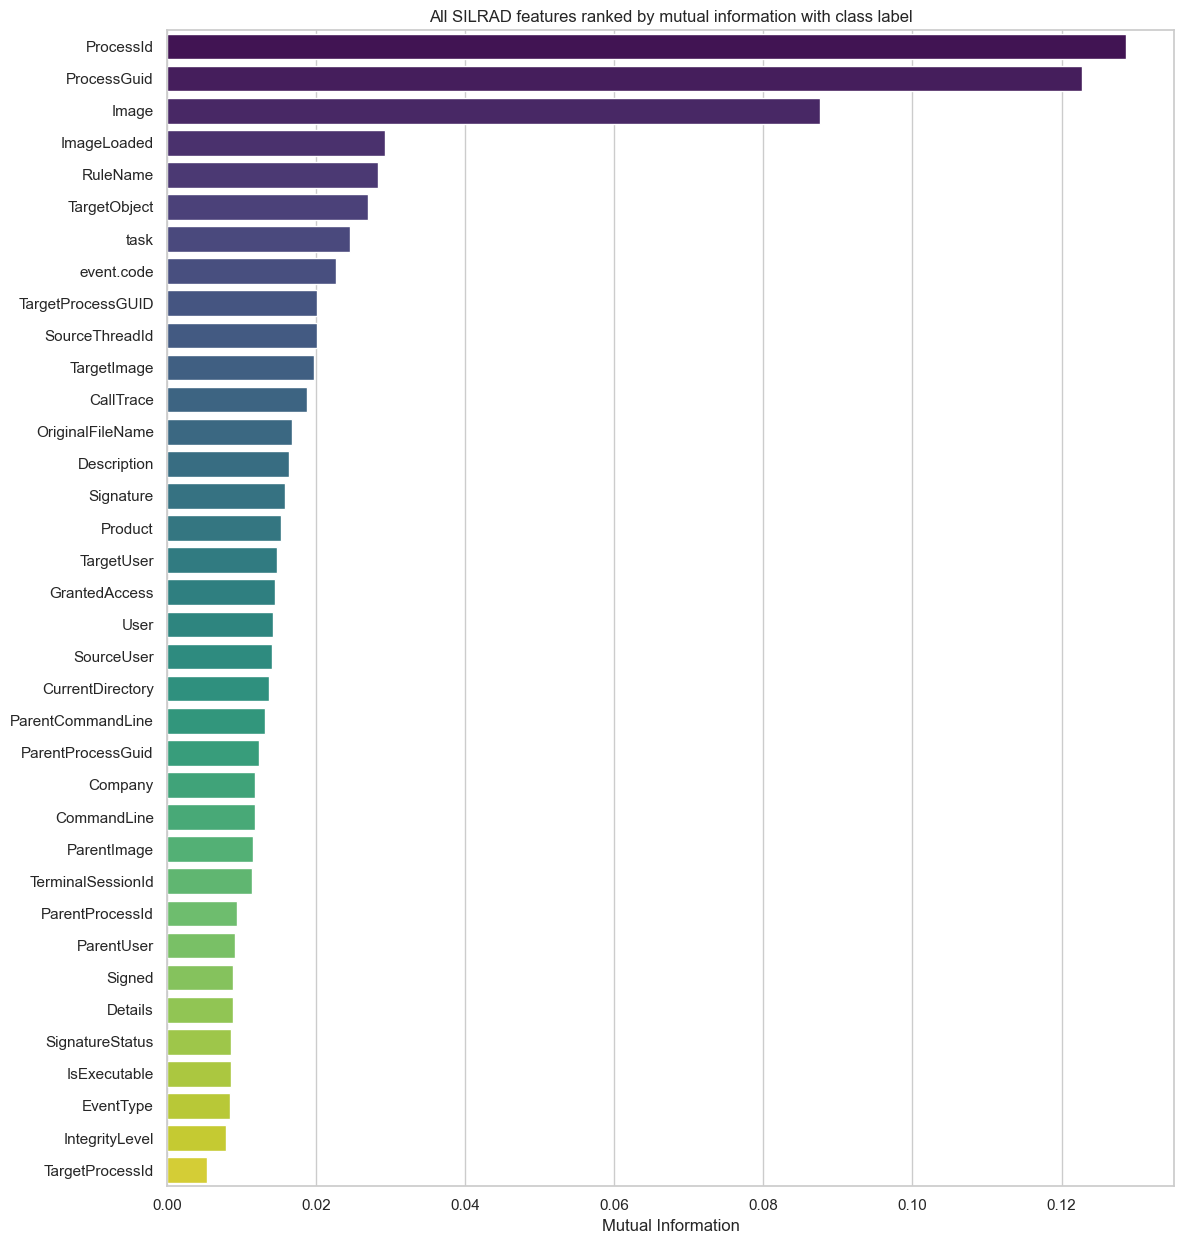

In [7]:
# Mutual information (ALL features)
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_train, y_train, random_state=42)
mi_df = pd.DataFrame({'feature': feat_names, 'mi': mi}).sort_values('mi', ascending=False).reset_index(drop=True)

print('All features ranked by mutual information with class label:')
display(mi_df)

fig_height = max(8, 0.35 * len(mi_df))
fig, ax = plt.subplots(figsize=(12, fig_height))
sns.barplot(data=mi_df, x='mi', y='feature', ax=ax, palette='viridis')
ax.set_title('All SILRAD features ranked by mutual information with class label')
ax.set_xlabel('Mutual Information')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Projection input shape: (39999, 36) (all rows, all features)


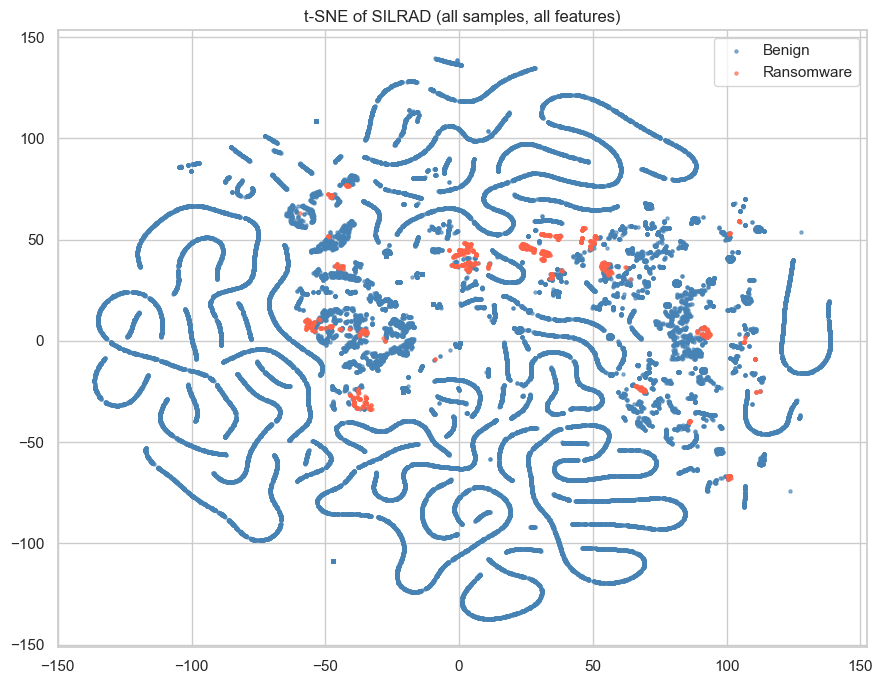

c:\Users\cesar\miniforge3\envs\cyber-anomaly\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\cesar\miniforge3\envs\cyber-anomaly\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


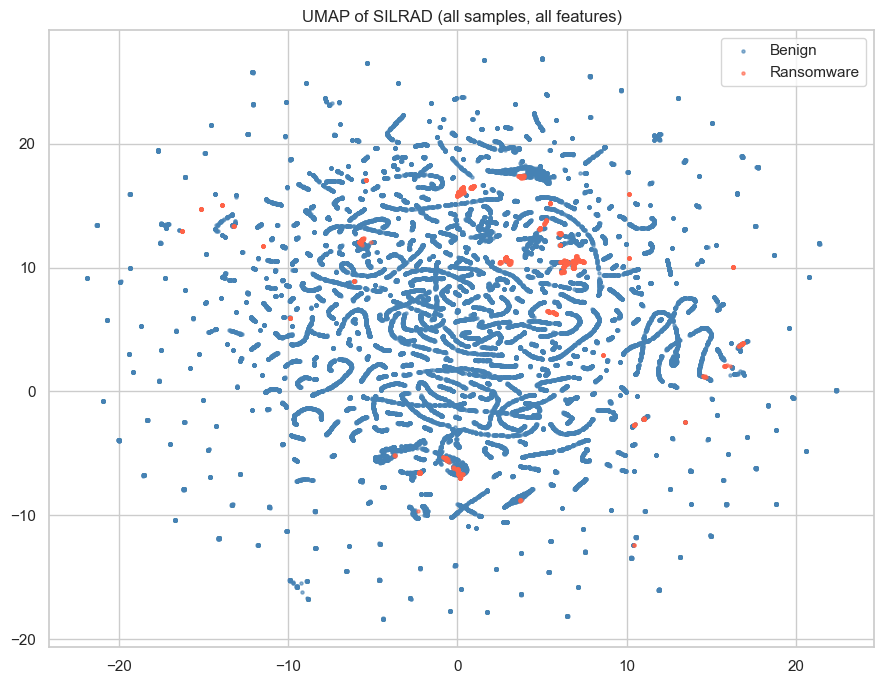

In [9]:
# t-SNE + UMAP projection using ALL rows and ALL features
from sklearn.manifold import TSNE

X_sub, y_sub = X_train, y_train
print(f'Projection input shape: {X_sub.shape} (all rows, all features)')

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
Z_tsne = tsne.fit_transform(X_sub)

fig, ax = plt.subplots(figsize=(9, 7))
for lbl, color, name in [(0, 'steelblue', 'Benign'), (1, 'tomato', 'Ransomware')]:
    mask = y_sub == lbl
    ax.scatter(Z_tsne[mask, 0], Z_tsne[mask, 1], s=5, c=color, label=name, alpha=0.6)
ax.set_title('t-SNE of SILRAD (all samples, all features)')
ax.legend()
plt.tight_layout()
plt.show()

# UMAP (if installed)
try:
    import umap.umap_ as umap
    umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
    Z_umap = umap_model.fit_transform(X_sub)

    fig, ax = plt.subplots(figsize=(9, 7))
    for lbl, color, name in [(0, 'steelblue', 'Benign'), (1, 'tomato', 'Ransomware')]:
        mask = y_sub == lbl
        ax.scatter(Z_umap[mask, 0], Z_umap[mask, 1], s=5, c=color, label=name, alpha=0.6)
    ax.set_title('UMAP of SILRAD (all samples, all features)')
    ax.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print('UMAP is not installed. Install with: pip install umap-learn')

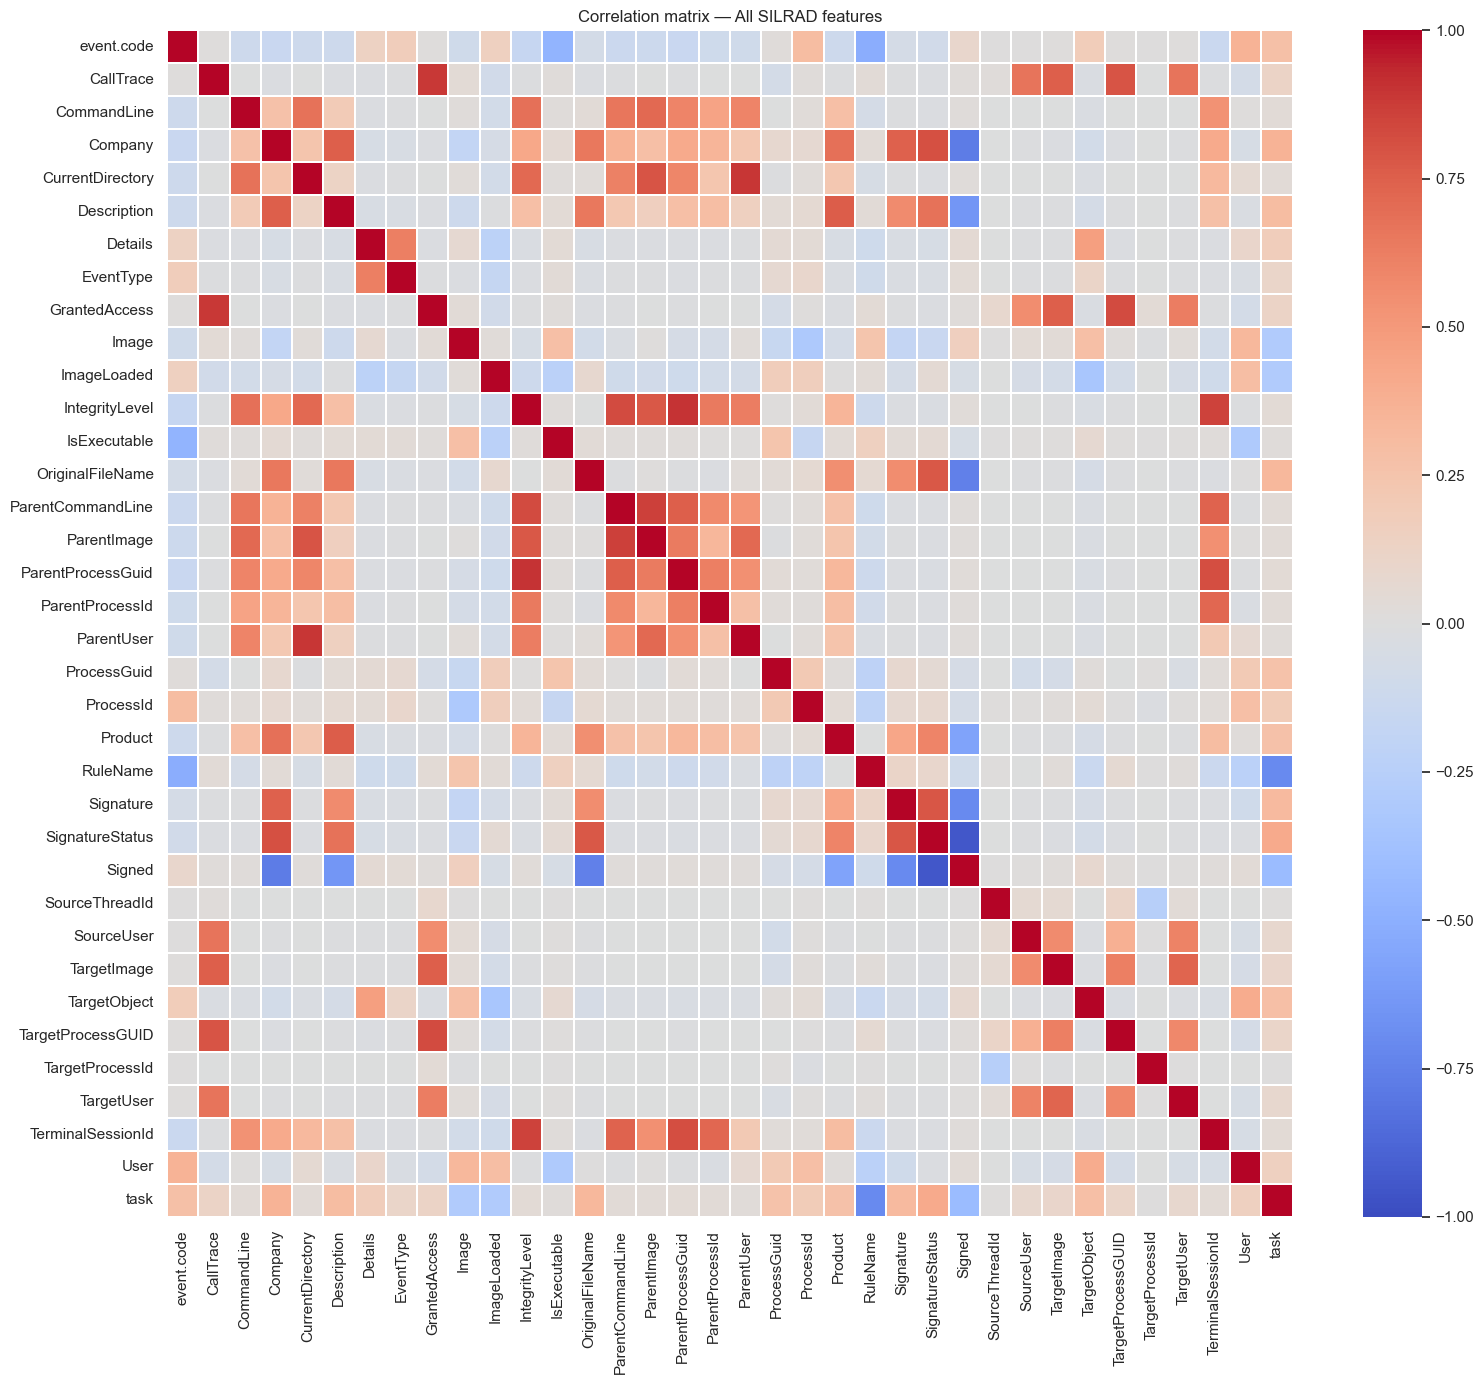

In [10]:
# Correlation heatmap of all features
corr = pd.DataFrame(X_train, columns=feat_names).corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, ax=ax, cmap='coolwarm', vmin=-1, vmax=1, annot=False, linewidths=0.2)
ax.set_title('Correlation matrix — All SILRAD features')
plt.tight_layout()
plt.show()

## Feature Subset Sweep (PCC vs MI)
This block mirrors the SILRAD paper's idea of testing performance with different numbers of top-ranked features.

- Ranking methods: **PCC** (absolute Pearson correlation) and **Mutual Information (MI)**
- Subset sizes: 5, 10, 15, 20, 25, and all features
- Classifier: Logistic Regression (`class_weight='balanced'`)
- Metrics: MCC, F1, Precision, Recall, Accuracy

,ranking,k,mcc,f1,precision,recall,accuracy
0,MI,5,0.296156,0.394075,0.307350,0.548978,0.789793
1,MI,10,0.349249,0.435477,0.336336,0.617492,0.800658
2,MI,15,0.378179,0.460463,0.367144,0.617390,0.819849
3,MI,20,0.313581,0.407727,0.316829,0.571765,0.793166
4,MI,25,0.310707,0.405474,0.315209,0.568181,0.792535
5,MI,36,0.337864,0.427968,0.340659,0.575452,0.808456
6,PCC,5,0.309659,0.405247,0.321707,0.547391,0.799938
7,PCC,10,0.354832,0.438997,0.335324,0.635465,0.797770
8,PCC,15,0.300959,0.397181,0.303956,0.572892,0.783469
9,PCC,20,0.300689,0.396918,0.303404,0.573762,0.782901


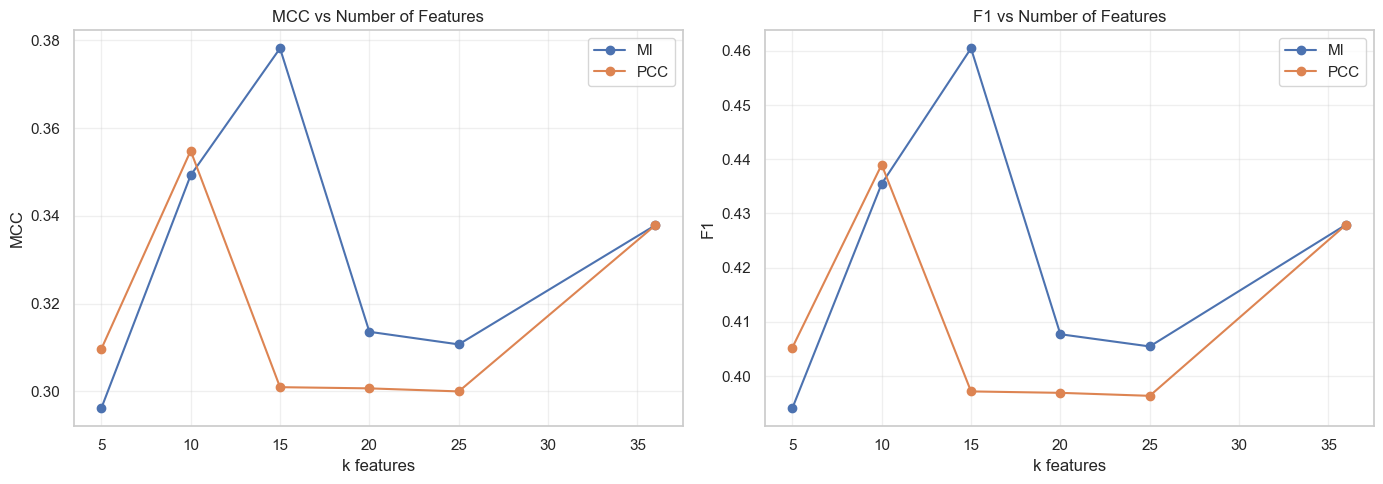


PCC ranking feature subsets:
k=5: ['ProcessGuid', 'SourceUser', 'CallTrace', 'GrantedAccess', 'TargetImage']
k=10: ['ProcessGuid', 'SourceUser', 'CallTrace', 'GrantedAccess', 'TargetImage', 'TargetUser', 'task', 'TargetProcessGUID', 'OriginalFileName', 'Image']
k=15: ['ProcessGuid', 'SourceUser', 'CallTrace', 'GrantedAccess', 'TargetImage', 'TargetUser', 'task', 'TargetProcessGUID', 'OriginalFileName', 'Image', 'ParentImage', 'User', 'RuleName', 'SignatureStatus', 'event.code']
k=20: ['ProcessGuid', 'SourceUser', 'CallTrace', 'GrantedAccess', 'TargetImage', 'TargetUser', 'task', 'TargetProcessGUID', 'OriginalFileName', 'Image', 'ParentImage', 'User', 'RuleName', 'SignatureStatus', 'event.code', 'Signed', 'CurrentDirectory', 'ParentUser', 'Product', 'TargetObject']
k=25: ['ProcessGuid', 'SourceUser', 'CallTrace', 'GrantedAccess', 'TargetImage', 'TargetUser', 'task', 'TargetProcessGUID', 'OriginalFileName', 'Image', 'ParentImage', 'User', 'RuleName', 'SignatureStatus', 'event.code', 'Si

In [11]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import matthews_corrcoef, f1_score, precision_score, recall_score, accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

n_total_features = X_train.shape[1]
k_values = [5, 10, 15, 20, 25, n_total_features]
k_values = sorted(set([k for k in k_values if 1 <= k <= n_total_features]))

# Rank by absolute PCC on training split
pcc_abs = []
for i in range(n_total_features):
    xi = X_train[:, i]
    if np.std(xi) == 0:
        score = 0.0
    else:
        score = np.corrcoef(xi, y_train)[0, 1]
        if np.isnan(score):
            score = 0.0
    pcc_abs.append(abs(float(score)))
pcc_rank_idx = np.argsort(np.array(pcc_abs))[::-1]

# Rank by Mutual Information on training split
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_rank_idx = np.argsort(mi_scores)[::-1]

def evaluate_subset(rank_idx, k):
    idx = rank_idx[:k]
    Xtr = X_train[:, idx]
    Xte = X_test[:, idx]

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            solver='liblinear',
            random_state=42,
        ),
    )
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    return {
        'k': int(k),
        'mcc': float(matthews_corrcoef(y_test, y_pred)),
        'f1': float(f1_score(y_test, y_pred, zero_division=0)),
        'precision': float(precision_score(y_test, y_pred, zero_division=0)),
        'recall': float(recall_score(y_test, y_pred, zero_division=0)),
        'accuracy': float(accuracy_score(y_test, y_pred)),
        'features': [feat_names[j] for j in idx],
    }

rows = []
for k in k_values:
    pcc_res = evaluate_subset(pcc_rank_idx, k)
    pcc_res['ranking'] = 'PCC'
    rows.append(pcc_res)

    mi_res = evaluate_subset(mi_rank_idx, k)
    mi_res['ranking'] = 'MI'
    rows.append(mi_res)

results_df = pd.DataFrame(rows).sort_values(['ranking', 'k']).reset_index(drop=True)
display(results_df[['ranking', 'k', 'mcc', 'f1', 'precision', 'recall', 'accuracy']])

# Plot MCC and F1 vs number of features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ranking, grp in results_df.groupby('ranking'):
    grp = grp.sort_values('k')
    axes[0].plot(grp['k'], grp['mcc'], marker='o', label=ranking)
    axes[1].plot(grp['k'], grp['f1'], marker='o', label=ranking)

axes[0].set_title('MCC vs Number of Features')
axes[0].set_xlabel('k features')
axes[0].set_ylabel('MCC')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title('F1 vs Number of Features')
axes[1].set_xlabel('k features')
axes[1].set_ylabel('F1')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Show selected feature names for each ranking / k
for ranking, rank_idx in [('PCC', pcc_rank_idx), ('MI', mi_rank_idx)]:
    print(f'\n{ranking} ranking feature subsets:')
    for k in k_values:
        selected = [feat_names[j] for j in rank_idx[:k]]
        print(f'k={k}: {selected}')